### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("./data/drugLibTrain_raw.tsv", sep="\t")


In [19]:
df

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above
...,...,...,...,...,...,...,...,...,...
3102,1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Bett...","Restless legs at night, insomnia, headache (so...","I took adderall once as a child, and it made m..."
3103,3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day,...",I was on Zoloft for about 2 years total. I am ...
3104,1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,Constant issues with the patch not staying on....,---
3105,2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked ...


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categoricas con pocas categorias (10 como mucho)

In [20]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         3107 non-null   int64
 1   urlDrugName        3107 non-null   str  
 2   rating             3107 non-null   int64
 3   effectiveness      3107 non-null   str  
 4   sideEffects        3107 non-null   str  
 5   condition          3106 non-null   str  
 6   benefitsReview     3089 non-null   str  
 7   sideEffectsReview  3032 non-null   str  
 8   commentsReview     3095 non-null   str  
dtypes: int64(2), str(7)
memory usage: 2.3 MB


In [21]:
df["commentsReview"].value_counts()

commentsReview
none                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [22]:
num_cols = ["Unnamed: 0"]
cat_cols = ["effectiveness", "rating", "sideEffects"]

<function matplotlib.pyplot.show(close=None, block=None)>

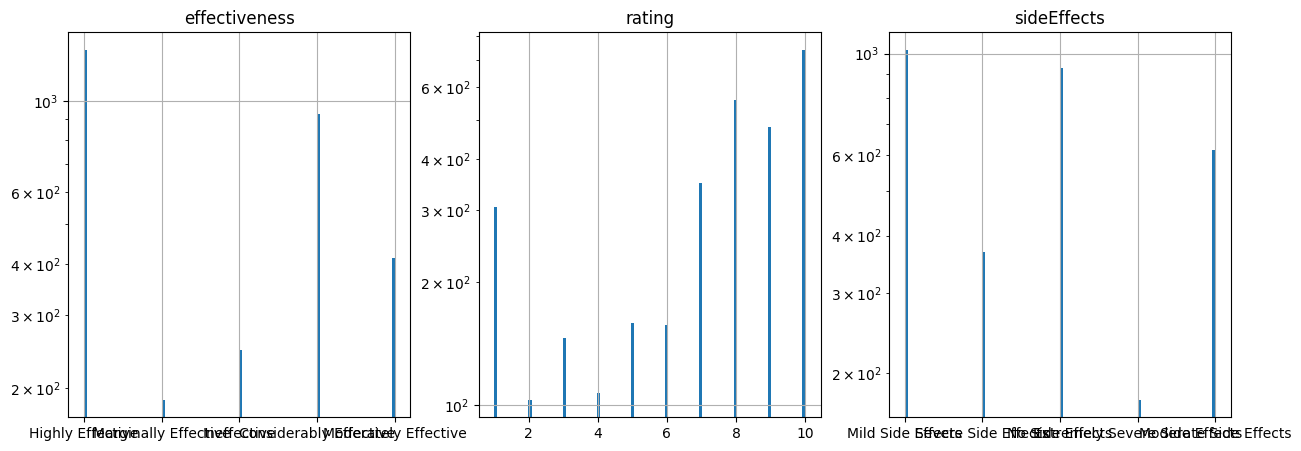

In [23]:

figure = plt.figure(figsize=(15,5))

for n, c in enumerate(df[cat_cols]):
  ax = figure.add_subplot(1,3,n+1)
  ax.set_title(c)
  ax.set_yscale("log")
  df[c].hist(ax=ax, bins=100)

plt.show

#### Transforma las columnas categoricas

Transforma las columnas categóricas no codificadas a numéricas mediante dummies.

In [24]:
df

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above
...,...,...,...,...,...,...,...,...,...
3102,1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Bett...","Restless legs at night, insomnia, headache (so...","I took adderall once as a child, and it made m..."
3103,3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day,...",I was on Zoloft for about 2 years total. I am ...
3104,1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,Constant issues with the patch not staying on....,---
3105,2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked ...


In [28]:

import pandas as pd
from sklearn.preprocessing import StandardScaler


df_proc = df[['rating', 'effectiveness', 'sideEffects']].copy()


dummies = pd.get_dummies(df_proc[['effectiveness', 'sideEffects']], drop_first=True) * 1


df_final = pd.concat([df_proc[['rating']], dummies], axis=1)


scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_final)
df_scaled

array([[-1.02349444,  1.15589369, -0.29387691, ..., -0.49627574,
        -0.65360033, -0.36711021],
       [-2.04490682,  1.15589369, -0.29387691, ..., -0.49627574,
        -0.65360033,  2.72397764],
       [ 1.01933033,  1.15589369, -0.29387691, ..., -0.49627574,
         1.529987  , -0.36711021],
       ...,
       [-1.70443603, -0.86513146, -0.29387691, ...,  2.01500883,
        -0.65360033, -0.36711021],
       [ 0.33838874, -0.86513146, -0.29387691, ..., -0.49627574,
        -0.65360033, -0.36711021],
       [-1.02349444, -0.86513146, -0.29387691, ...,  2.01500883,
        -0.65360033, -0.36711021]], shape=(3107, 9))

#### Evalúa cuál es la mejor K

Utiliza silhouette_score para evaluar cuál es la mejor K. Evalúa como mucho K = 20

#### Genera el K Means 

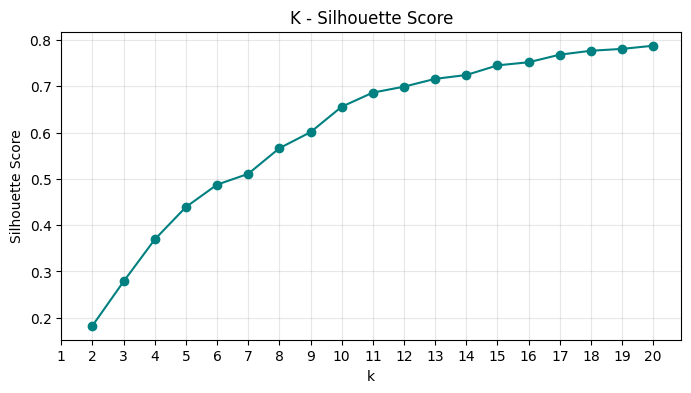

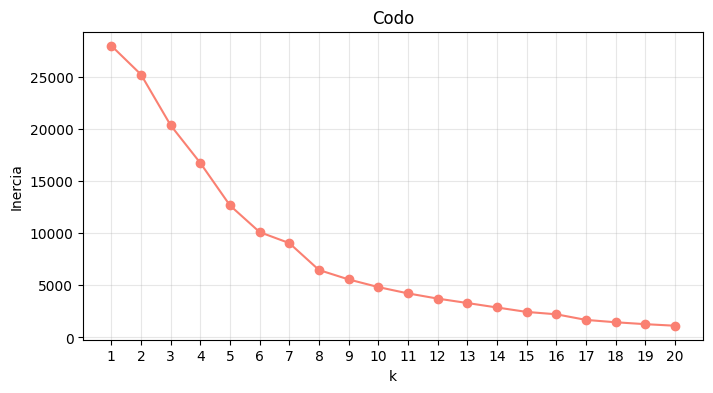

K según Silhouette Score: 20


In [30]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

k_values = list(range(1, 21))
scores = []
inercias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    inercias.append(kmeans.inertia_)
    
    if k >= 2:
        scores.append(silhouette_score(df_scaled, labels))
    else:
        scores.append(None)


plt.figure(figsize=(8, 4))
plt.plot(k_values[1:], scores[1:], marker='o', linestyle='-', color='teal')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('K - Silhouette Score')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(k_values, inercias, marker='o', linestyle='-', color='salmon')
plt.xlabel('k')
plt.ylabel('Inercia')
plt.title('Codo')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()


k_optimo = k_values[1:][scores[1:].index(max(scores[1:]))]
print(f"K según Silhouette Score: {k_optimo}")

In [35]:

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42)
etiquetas = kmeans_final.fit_predict(df_scaled)
cluster_counts = pd.Series(etiquetas).value_counts().sort_index()

cluster_counts

0     206
1      81
2     362
3     528
4     125
5      52
6      56
7     119
8     484
9     254
10    148
11     67
12    197
13     55
14     85
15     43
16     76
17     46
18     86
19     37
Name: count, dtype: int64

#### Muestra en un gráfico de quesito la distribución de los distintos clusters

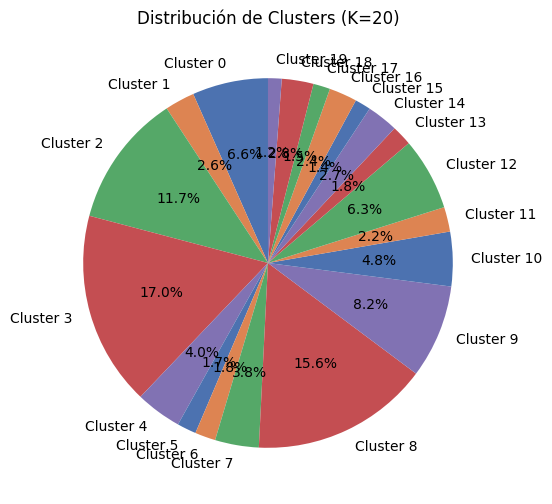

In [34]:

plt.figure(figsize=(6, 6))
plt.pie(cluster_counts, 
        labels=[f'Cluster {i}' for i in cluster_counts.index],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3'])
plt.title(f'Distribución de Clusters (K={k_optimo})')
plt.show()

